# 00 — Claude Code demo: skeleton visualization

A scratch notebook for trying the **edit-and-run-plots loop** with Claude Code's native
`.ipynb` support (read cells + outputs, edit cells via NotebookEdit).

It loads the repo's bundled sample (`sample_data/self_selected_gait_speed/front__2024-01-09.csv`)
— a 32-joint Azure Kinect skeleton, self-selected gait speed — and makes two plots.

**How to use:** run all cells once, then ask Claude Code things like *"in the demo notebook,
color the left leg red"* or *"add a 3D scatter of one frame"*. Claude edits the cell; you re-run it.

> Research/EDA only — per `CLAUDE.md`, notebooks are not production code.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the sample CSV by walking up from the notebook to the repo root.
_here = Path.cwd()
_root = next(p for p in [_here, *_here.parents] if (p / "sample_data").is_dir())
CSV = _root / "sample_data" / "self_selected_gait_speed" / "front__2024-01-09.csv"

df = pd.read_csv(CSV)
print(f"{CSV.relative_to(_root)}  ->  {df.shape[0]} frames, {df.shape[1]} columns")

sample_data/self_selected_gait_speed/front__2024-01-09.csv  ->  1829 frames, 258 columns


In [2]:
# Reshape the flat columns into an array of shape [frames, joints, 3] (x, y, z in mm).
# Position columns look like '0_PELVIS_x'; the quaternion '..._angle_*' columns are skipped.
joint_names = [c[:-2] for c in df.columns if c.endswith("_x") and not c.endswith("_angle_x")]

xyz = np.stack(
    [df[[f"{j}_x", f"{j}_y", f"{j}_z"]].to_numpy(dtype=float) for j in joint_names],
    axis=1,
)  # [T, J, 3]

T, J, _ = xyz.shape
print(f"{T} frames x {J} joints")
print("joints:", ", ".join(joint_names))

1829 frames x 32 joints
joints: 0_PELVIS, 1_SPINE_NAVEL, 2_SPINE_CHEST, 3_NECK, 4_CLAVICLE_LEFT, 5_SHOULDER_LEFT, 6_ELBOW_LEFT, 7_WRIST_LEFT, 8_HAND_LEFT, 9_HANDTIP_LEFT, 10_THUMB_LEFT, 11_CLAVICLE_RIGHT, 12_SHOULDER_RIGHT, 13_ELBOW_RIGHT, 14_WRIST_RIGHT, 15_HAND_RIGHT, 16_HANDTIP_RIGHT, 17_THUMB_RIGHT, 18_HIP_LEFT, 19_KNEE_LEFT, 20_ANKLE_LEFT, 21_FOOT_LEFT, 22_HIP_RIGHT, 23_KNEE_RIGHT, 24_ANKLE_RIGHT, 25_FOOT_RIGHT, 26_HEAD, 27_NOSE, 28_EYE_LEFT, 29_EAR_LEFT, 30_EYE_RIGHT, 31_EAR_RIGHT


In [3]:
# Bone connectivity for the 32-joint Azure Kinect (k4abt) skeleton: (parent_idx, child_idx).
BONES = [
    (0, 1), (1, 2), (2, 3), (3, 26), (26, 27),          # spine + head
    (27, 28), (28, 29), (27, 30), (30, 31),             # face
    (2, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (7, 10),   # left arm
    (2, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (14, 17),  # right arm
    (0, 18), (18, 19), (19, 20), (20, 21),              # left leg
    (0, 22), (22, 23), (23, 24), (24, 25),              # right leg
]

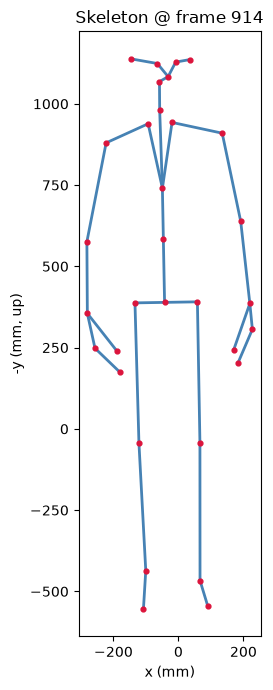

In [4]:
# Plot 1 — skeleton stick figure at a single frame (front view: x horizontal, y vertical).
# Kinect y points downward, so negate it to draw the subject upright.
frame = T // 2
pts = xyz[frame]

fig, ax = plt.subplots(figsize=(4, 7))
for a, b in BONES:
    ax.plot([pts[a, 0], pts[b, 0]], [-pts[a, 1], -pts[b, 1]], "-", color="steelblue", lw=2)
ax.scatter(pts[:, 0], -pts[:, 1], s=12, color="crimson", zorder=3)
ax.set_aspect("equal")
ax.set_title(f"Skeleton @ frame {frame}")
ax.set_xlabel("x (mm)")
ax.set_ylabel("-y (mm, up)")
plt.tight_layout()
plt.show()

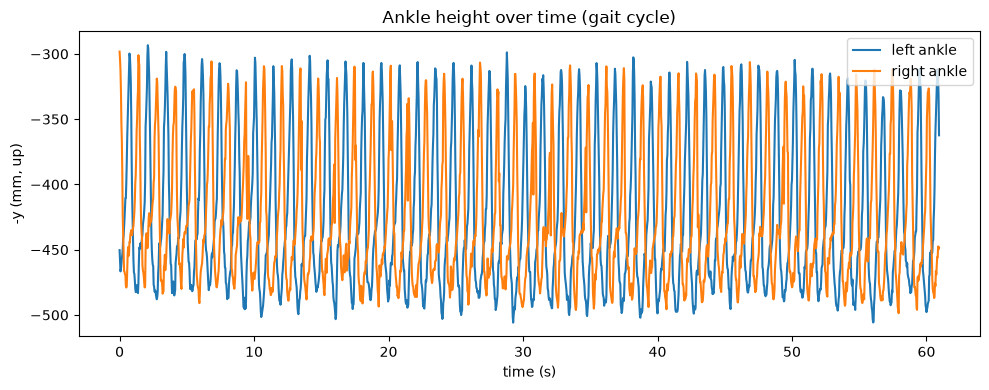

In [5]:
# Plot 2 — vertical position of both ankles over time: the up/down oscillation is the gait cycle.
t = df["timestamp_usec"].to_numpy(dtype=float)
t = (t - t[0]) / 1e6  # seconds

la = joint_names.index("20_ANKLE_LEFT")
ra = joint_names.index("24_ANKLE_RIGHT")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, -xyz[:, la, 1], label="left ankle", color="tab:blue")
ax.plot(t, -xyz[:, ra, 1], label="right ankle", color="tab:orange")
ax.set_title("Ankle height over time (gait cycle)")
ax.set_xlabel("time (s)")
ax.set_ylabel("-y (mm, up)")
ax.legend()
plt.tight_layout()
plt.show()

## Try the edit-and-run loop

Ask Claude Code to edit a cell, then re-run it yourself:
- *"In Plot 1, color the left arm and left leg red, the right side green."*
- *"Change Plot 1 to a side view (z horizontal instead of x)."*
- *"Add a cell with a 3D scatter (`projection='3d'`) of the mid-frame skeleton."*
- *"In Plot 2, plot horizontal stride (z) instead of vertical, and mark heel-strike peaks."*

To run headless (Claude can do this for you):
```bash
jupyter nbconvert --to notebook --execute --inplace notebooks/00_claude_code_demo_skeleton_viz.ipynb
```